# Laboratorio 7: análisis exploratorio, correlaciones y segmentación

Este notebook desarrolla las actividades 2, 3 y 4 con la población analítica de 2025 preparada en el inciso 1. Las estadísticas y métricas se calculan con todos los registros elegibles en Spark; únicamente las tablas agregadas y una muestra máxima de 10,000 registros se transfieren a pandas para graficar.

> **Control de integridad:** los resultados solo son válidos después de regenerar `df_2025.parquet` con los cuatro archivos trimestrales correctos. El notebook comprueba columnas y períodos, pero no puede corregir errores de procedencia del inciso 1.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("Lab7-EDA-Clustering")
    .master("local[*]")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
sns.set_theme(style="whitegrid", context="notebook")
print(f"Spark {spark.version}")

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/27 18:51:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1


In [2]:
parquet_candidates = [
    "/opt/app/notebooks/df_2025.parquet",
    "df_2025.parquet",
    "notebooks/df_2025.parquet",
]
parquet_path = next((path for path in parquet_candidates if os.path.exists(path)), None)
if parquet_path is None:
    raise FileNotFoundError("No se encontró df_2025.parquet. Ejecute primero el inciso 1.")

df_2025 = spark.read.parquet(parquet_path)
required_columns = {
    "salario_mensual", "edad", "antiguedad_total", "horas_semanales",
    "nivel_educativo", "categoria_ocupacional", "dominio", "periodo_archivo"
}
missing_columns = sorted(required_columns - set(df_2025.columns))
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {missing_columns}")

df_2025 = df_2025.cache()
n_observaciones = df_2025.count()
periodos = [row["periodo_archivo"] for row in df_2025.select("periodo_archivo").distinct().orderBy("periodo_archivo").collect()]
if periodos != ["2025T1", "2025T2", "2025T3", "2025T4"]:
    raise ValueError(f"Se esperaban los cuatro períodos de 2025 y se encontraron: {periodos}")

print(f"Ruta: {parquet_path}")
print(f"Observaciones elegibles de 2025: {n_observaciones:,}")
print(f"Períodos: {periodos}")
df_2025.select(*sorted(required_columns)).printSchema()

Ruta: /opt/app/notebooks/df_2025.parquet
Observaciones elegibles de 2025: 53,676
Períodos: ['2025T1', '2025T2', '2025T3', '2025T4']
root
 |-- antiguedad_total: double (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- edad: long (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- salario_mensual: double (nullable = true)



## 2. Estadística descriptiva y preguntas de exploración

Se resumen salario mensual, edad, antigüedad y horas habituales. Los percentiles se calculan con `percentile_approx` sobre la base completa. El análisis es no ponderado: describe los registros analizados y no constituye una estimación oficial de la población guatemalteca.

In [3]:
numeric_columns = ["salario_mensual", "edad", "antiguedad_total", "horas_semanales"]
numeric_labels = {
    "salario_mensual": "Salario mensual (Q)",
    "edad": "Edad (años)",
    "antiguedad_total": "Antigüedad (años)",
    "horas_semanales": "Horas semanales",
}

aggregations = []
for column in numeric_columns:
    aggregations.extend([
        F.count(column).alias(f"{column}__n"),
        F.avg(column).alias(f"{column}__media"),
        F.stddev_samp(column).alias(f"{column}__desviacion"),
        F.min(column).alias(f"{column}__minimo"),
        F.max(column).alias(f"{column}__maximo"),
        F.percentile_approx(column, [0.25, 0.50, 0.75, 0.95], 10000).alias(f"{column}__percentiles"),
    ])

summary_row = df_2025.agg(*aggregations).first().asDict()
summary_records = []
for column in numeric_columns:
    p25, median, p75, p95 = summary_row[f"{column}__percentiles"]
    summary_records.append({
        "variable": numeric_labels[column],
        "n": summary_row[f"{column}__n"],
        "media": summary_row[f"{column}__media"],
        "mediana": median,
        "desviación estándar": summary_row[f"{column}__desviacion"],
        "mínimo": summary_row[f"{column}__minimo"],
        "máximo": summary_row[f"{column}__maximo"],
        "P25": p25, "P75": p75, "P95": p95,
    })
summary_pdf = pd.DataFrame(summary_records).set_index("variable")
display(summary_pdf.round(2))

,n,media,mediana,desviación estándar,mínimo,máximo,P25,P75,P95
variable,,,,,,,,,
Salario mensual (Q),53676,3315.63,3000.0,2935.47,100.0,99000.0,1600.00,3960.0,8000.0
Edad (años),53676,35.07,33.0,13.52,15.0,89.0,24.00,44.0,61.0
Antigüedad (años),53676,5.78,2.5,7.98,0.0,64.0,0.67,8.0,22.0
Horas semanales,53676,45.91,45.0,19.23,1.0,126.0,40.00,54.0,80.0


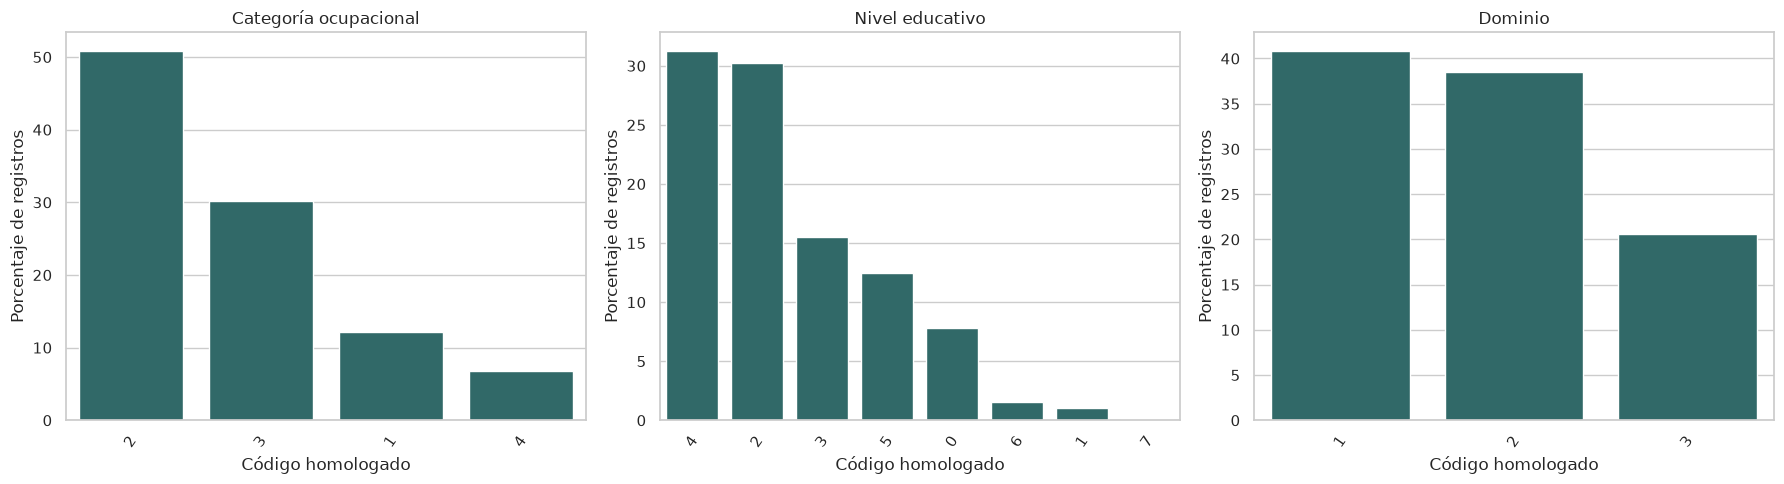

**Categoría ocupacional**

,categoria_ocupacional,observaciones,porcentaje
0,2,27300,50.86
1,3,16228,30.23
2,1,6492,12.09
3,4,3656,6.81


**Nivel educativo**

,nivel_educativo,observaciones,porcentaje
0,4,16784,31.27
1,2,16248,30.27
2,3,8316,15.49
3,5,6696,12.47
4,0,4200,7.82
5,6,808,1.51
6,1,552,1.03
7,7,72,0.13


**Dominio**

,dominio,observaciones,porcentaje
0,1,21924,40.85
1,2,20668,38.51
2,3,11084,20.65


In [4]:
categorical_columns = ["categoria_ocupacional", "nivel_educativo", "dominio"]
categorical_labels = {
    "categoria_ocupacional": "Categoría ocupacional",
    "nivel_educativo": "Nivel educativo",
    "dominio": "Dominio",
}
category_tables = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, column in zip(axes, categorical_columns):
    table = (
        df_2025.groupBy(column)
        .agg(F.count("*").alias("observaciones"))
        .withColumn("porcentaje", F.round(F.col("observaciones") * 100 / F.lit(n_observaciones), 2))
        .orderBy(F.desc("observaciones"))
    )
    category_tables[column] = table
    table_pdf = table.toPandas()
    sns.barplot(data=table_pdf, x=column, y="porcentaje", ax=axis, color="#287271")
    axis.set_title(categorical_labels[column])
    axis.set_xlabel("Código homologado")
    axis.set_ylabel("Porcentaje de registros")
    axis.tick_params(axis="x", rotation=55)
plt.tight_layout()
plt.show()

for column in categorical_columns:
    display(Markdown(f"**{categorical_labels[column]}**"))
    display(category_tables[column].toPandas())

Registros usados únicamente para las gráficas: 10,000


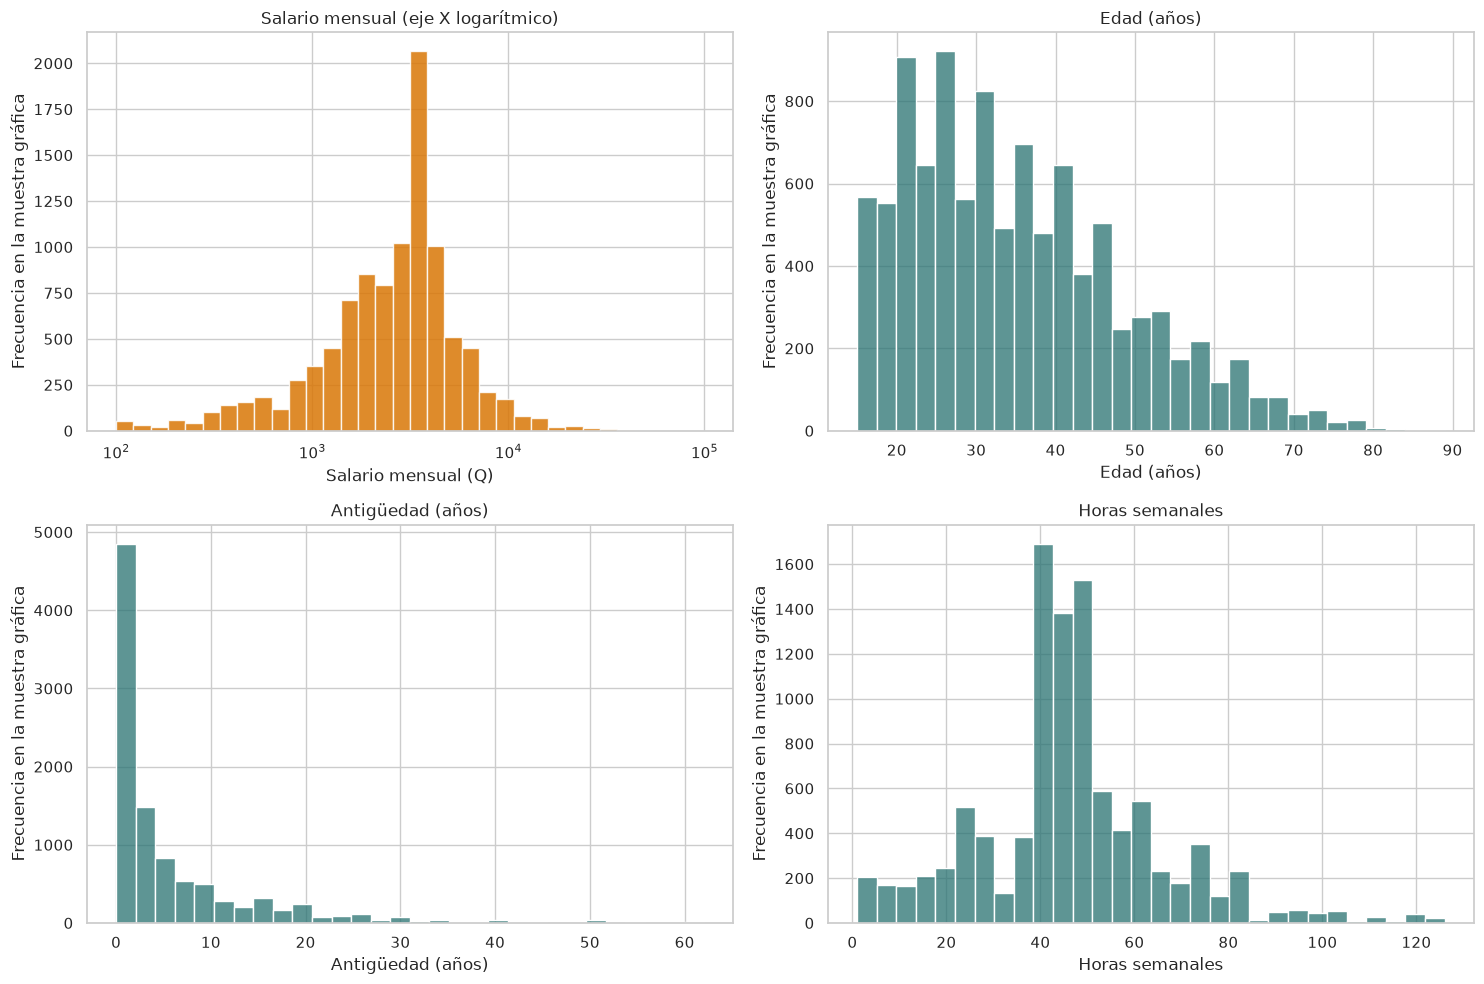

In [5]:
sample_fraction = min(1.0, 12000 / n_observaciones)
plot_sample = (
    df_2025.select(*numeric_columns)
    .sample(withReplacement=False, fraction=sample_fraction, seed=42)
    .limit(10000)
    .toPandas()
)
print(f"Registros usados únicamente para las gráficas: {len(plot_sample):,}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for axis, column in zip(axes.flat, numeric_columns):
    if column == "salario_mensual":
        positive = plot_sample.loc[plot_sample[column] > 0, column]
        bins = np.logspace(np.log10(positive.min()), np.log10(positive.max()), 35)
        axis.hist(positive, bins=bins, color="#D97706", alpha=0.85)
        axis.set_xscale("log")
        axis.set_title("Salario mensual (eje X logarítmico)")
    else:
        sns.histplot(data=plot_sample, x=column, bins=30, ax=axis, color="#287271")
        axis.set_title(numeric_labels[column])
    axis.set_xlabel(numeric_labels[column])
    axis.set_ylabel("Frecuencia en la muestra gráfica")
plt.tight_layout()
plt.show()

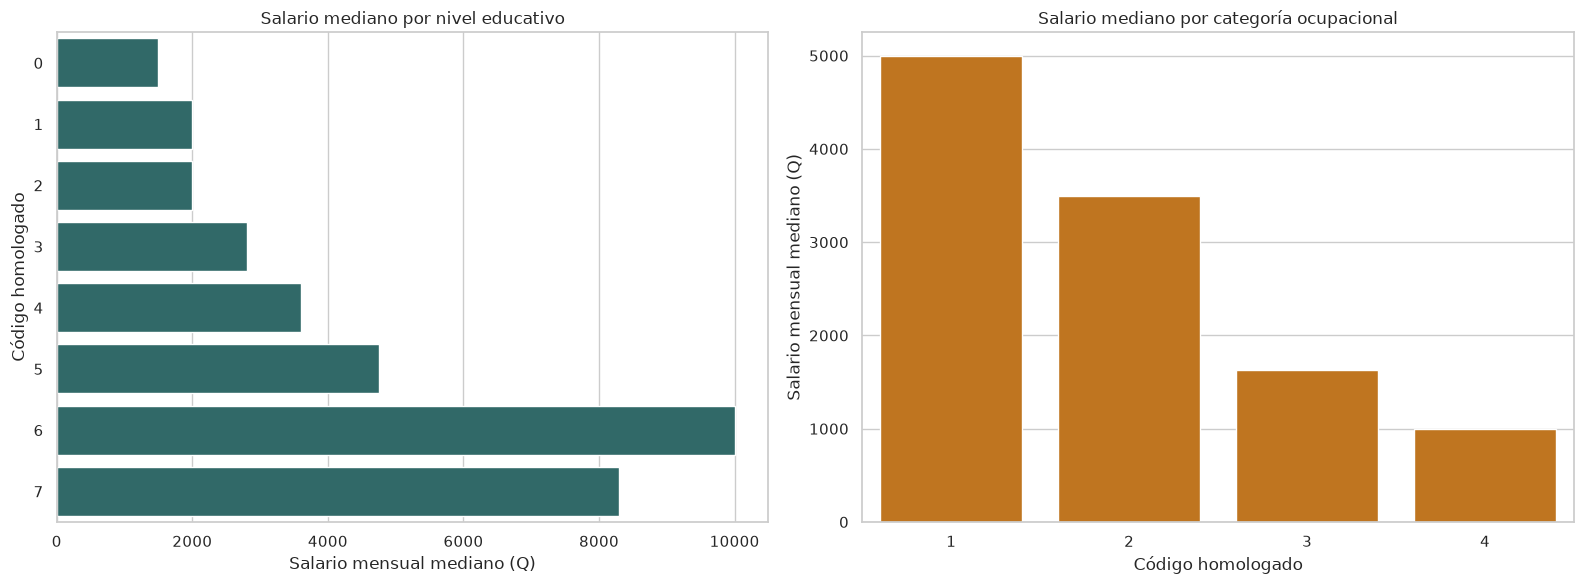

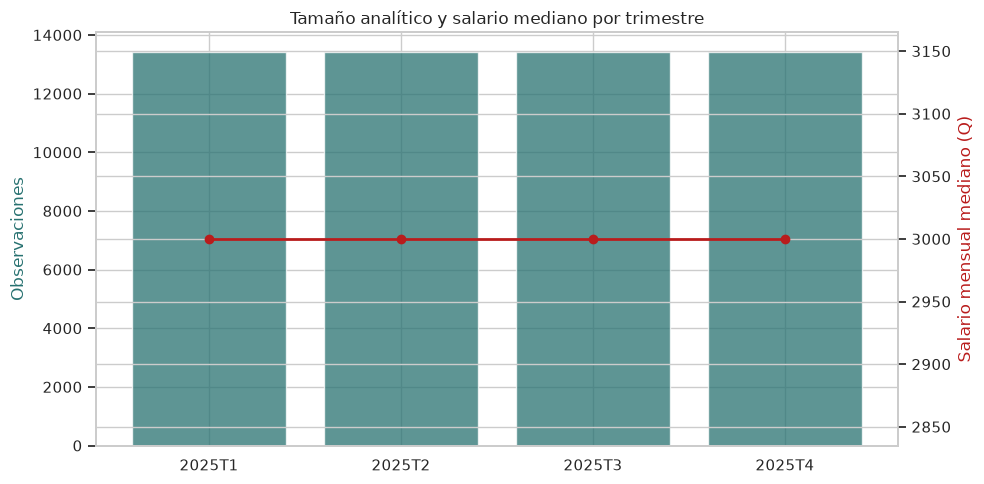

,periodo_archivo,observaciones,salario_mediano
0,2025T1,13419,3000.0
1,2025T2,13419,3000.0
2,2025T3,13419,3000.0
3,2025T4,13419,3000.0


In [6]:
def grouped_salary_summary(group_column):
    return (
        df_2025.groupBy(group_column)
        .agg(
            F.count("*").alias("observaciones"),
            F.percentile_approx("salario_mensual", 0.5, 10000).alias("salario_mediano"),
        )
        .orderBy(group_column)
    )

salary_education_pdf = grouped_salary_summary("nivel_educativo").toPandas()
salary_occupation_pdf = grouped_salary_summary("categoria_ocupacional").toPandas()
salary_quarter_pdf = grouped_salary_summary("periodo_archivo").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=salary_education_pdf, x="salario_mediano", y="nivel_educativo", ax=axes[0], color="#287271")
axes[0].set_title("Salario mediano por nivel educativo")
axes[0].set_xlabel("Salario mensual mediano (Q)")
axes[0].set_ylabel("Código homologado")
sns.barplot(data=salary_occupation_pdf, x="categoria_ocupacional", y="salario_mediano", ax=axes[1], color="#D97706")
axes[1].set_title("Salario mediano por categoría ocupacional")
axes[1].set_xlabel("Código homologado")
axes[1].set_ylabel("Salario mensual mediano (Q)")
plt.tight_layout()
plt.show()

fig, axis_count = plt.subplots(figsize=(10, 5))
axis_salary = axis_count.twinx()
axis_count.bar(salary_quarter_pdf["periodo_archivo"], salary_quarter_pdf["observaciones"], color="#287271", alpha=0.75)
axis_salary.plot(salary_quarter_pdf["periodo_archivo"], salary_quarter_pdf["salario_mediano"], color="#B91C1C", marker="o", linewidth=2)
axis_count.set_ylabel("Observaciones", color="#287271")
axis_salary.set_ylabel("Salario mensual mediano (Q)", color="#B91C1C")
axis_count.set_title("Tamaño analítico y salario mediano por trimestre")
plt.tight_layout()
plt.show()
display(salary_quarter_pdf)

In [7]:
salary_stats = summary_pdf.loc["Salario mensual (Q)"]
salary_gap = salary_stats["media"] - salary_stats["mediana"]
largest_occupation = category_tables["categoria_ocupacional"].first()
largest_education = category_tables["nivel_educativo"].first()
largest_domain = category_tables["dominio"].first()

shape_text = (
    "asimétrica hacia la derecha" if salary_gap > 0
    else "aproximadamente simétrica" if abs(salary_gap) < 0.05 * salary_stats["mediana"]
    else "asimétrica hacia la izquierda"
)
display(Markdown(f"""
### Interpretación de la actividad 2

- La categoría ocupacional con más registros es `{largest_occupation['categoria_ocupacional']}` ({largest_occupation['porcentaje']:.2f}%), el nivel educativo más frecuente es `{largest_education['nivel_educativo']}` ({largest_education['porcentaje']:.2f}%) y el dominio predominante es `{largest_domain['dominio']}` ({largest_domain['porcentaje']:.2f}%). Estas proporciones describen la muestra analítica no ponderada.
- El salario tiene una distribución **{shape_text}**. Su media es Q{salary_stats['media']:,.2f} y su mediana Q{salary_stats['mediana']:,.2f}; la diferencia de Q{salary_gap:,.2f} indica cuánto influyen los salarios alejados del centro. El P95 (Q{salary_stats['P95']:,.2f}) y el máximo (Q{salary_stats['máximo']:,.2f}) permiten observar la extensión de la cola superior.
- Las comparaciones por educación y categoría ocupacional muestran diferencias descriptivas entre grupos, pero no prueban causalidad. También deben leerse junto con el número de observaciones de cada grupo.
- La gráfica trimestral permite comparar simultáneamente cobertura analítica y salario mediano. Una variación entre períodos puede reflejar cambios de composición de la muestra, además de cambios salariales.
- El salario se mantiene en quetzales sin recortes ni transformación para los cálculos. La escala logarítmica se utilizó solamente para visualizar su distribución.
"""))


### Interpretación de la actividad 2

- La categoría ocupacional con más registros es `2` (50.86%), el nivel educativo más frecuente es `4` (31.27%) y el dominio predominante es `1` (40.85%). Estas proporciones describen la muestra analítica no ponderada.
- El salario tiene una distribución **asimétrica hacia la derecha**. Su media es Q3,315.63 y su mediana Q3,000.00; la diferencia de Q315.63 indica cuánto influyen los salarios alejados del centro. El P95 (Q8,000.00) y el máximo (Q99,000.00) permiten observar la extensión de la cola superior.
- Las comparaciones por educación y categoría ocupacional muestran diferencias descriptivas entre grupos, pero no prueban causalidad. También deben leerse junto con el número de observaciones de cada grupo.
- La gráfica trimestral permite comparar simultáneamente cobertura analítica y salario mediano. Una variación entre períodos puede reflejar cambios de composición de la muestra, además de cambios salariales.
- El salario se mantiene en quetzales sin recortes ni transformación para los cálculos. La escala logarítmica se utilizó solamente para visualizar su distribución.


## 3. Relaciones entre variables numéricas

La correlación de Pearson se calcula con `VectorAssembler` y `Correlation.corr()` sobre todos los registros elegibles de 2025. La correlación mide asociación lineal; no implica causalidad.

,Salario,Edad,Antigüedad,Horas semanales
Salario,1.0000,0.1525,0.1658,0.0824
Edad,0.1525,1.0000,0.4912,-0.0914
Antigüedad,0.1658,0.4912,1.0000,-0.0564
Horas semanales,0.0824,-0.0914,-0.0564,1.0000


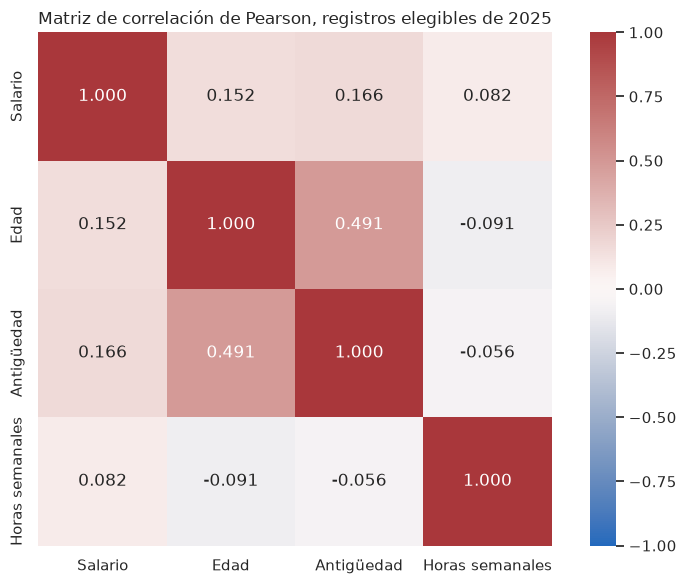


### Interpretación de la actividad 3

- La mayor asociación lineal absoluta con el salario corresponde a **Antigüedad**, con $r=0.166$. Las demás asociaciones con salario son: Edad: 0.152, Horas semanales: 0.082.
- La correlación entre edad y antigüedad es $r=0.491$. Su signo indica la dirección de la relación y su magnitud la intensidad lineal; aun una correlación positiva no significa que la edad cause mayor antigüedad.
- Las correlaciones pueden ser sensibles a salarios extremos y no capturan relaciones no lineales.


In [8]:
correlation_columns = ["salario_mensual", "edad", "antiguedad_total", "horas_semanales"]
correlation_labels = ["Salario", "Edad", "Antigüedad", "Horas semanales"]
correlation_input = VectorAssembler(inputCols=correlation_columns, outputCol="correlation_features").transform(df_2025)
correlation_matrix = Correlation.corr(correlation_input, "correlation_features", "pearson").first()[0].toArray()
correlation_pdf = pd.DataFrame(correlation_matrix, index=correlation_labels, columns=correlation_labels)
display(correlation_pdf.round(4))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_pdf, annot=True, fmt=".3f", cmap="vlag", center=0, vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación de Pearson, registros elegibles de 2025")
plt.tight_layout()
plt.show()

salary_correlations = correlation_pdf.loc["Salario"].drop("Salario").sort_values(key=lambda values: values.abs(), ascending=False)
strongest_variable = salary_correlations.index[0]
strongest_value = salary_correlations.iloc[0]
age_tenure = correlation_pdf.loc["Edad", "Antigüedad"]
display(Markdown(f"""
### Interpretación de la actividad 3

- La mayor asociación lineal absoluta con el salario corresponde a **{strongest_variable}**, con $r={strongest_value:.3f}$. Las demás asociaciones con salario son: {', '.join(f'{name}: {value:.3f}' for name, value in salary_correlations.iloc[1:].items())}.
- La correlación entre edad y antigüedad es $r={age_tenure:.3f}$. Su signo indica la dirección de la relación y su magnitud la intensidad lineal; aun una correlación positiva no significa que la edad cause mayor antigüedad.
- Las correlaciones pueden ser sensibles a salarios extremos y no capturan relaciones no lineales.
"""))

## 4. Segmentación de perfiles mediante KMeans

Se utilizan **edad, antigüedad y horas semanales** para identificar perfiles personales y laborales. El salario no se incluye al ajustar KMeans porque es la variable objetivo posterior, presenta una cola derecha pronunciada y podría convertir la segmentación en una separación casi exclusiva por ingresos. En cambio, se usa después para describir económicamente los grupos. Esta decisión evita que los salarios extremos dominen las distancias, pero implica que los clústeres no buscan maximizar diferencias salariales.

Las tres variables se estandarizan para que sus unidades y escalas no determinen el resultado. Se comparan K = 2, 3, 4 y 5 mediante silhouette con distancia euclidiana al cuadrado.

In [9]:
cluster_columns = ["edad", "antiguedad_total", "horas_semanales"]
cluster_assembler = VectorAssembler(inputCols=cluster_columns, outputCol="cluster_raw_features")
cluster_assembled = cluster_assembler.transform(df_2025)
cluster_scaler = StandardScaler(
    inputCol="cluster_raw_features", outputCol="cluster_features", withMean=True, withStd=True
)
cluster_scaler_model = cluster_scaler.fit(cluster_assembled)
cluster_data = cluster_scaler_model.transform(cluster_assembled).cache()
print(f"Registros usados en KMeans: {cluster_data.count():,}")

Registros usados en KMeans: 53,676


,K,silhouette,costo_interno
0,2,0.5548,108212.8949
1,3,0.4215,85729.3968
2,4,0.4403,70493.9459
3,5,0.4804,56216.8544


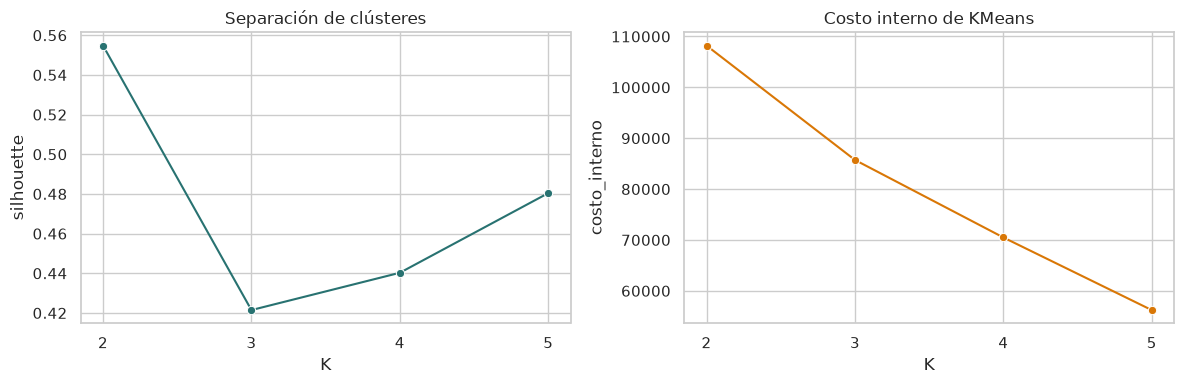

Se selecciona **K = 2** porque obtiene el mayor silhouette entre las cuatro alternativas. El costo interno se presenta como evidencia complementaria: siempre tiende a disminuir al aumentar K y no debe usarse por sí solo.

In [10]:
cluster_evaluator = ClusteringEvaluator(
    featuresCol="cluster_features", predictionCol="prediction",
    metricName="silhouette", distanceMeasure="squaredEuclidean",
)
k_results = []
for k in [2, 3, 4, 5]:
    candidate = KMeans(
        k=k, seed=42, featuresCol="cluster_features", predictionCol="prediction", maxIter=50
    ).fit(cluster_data)
    candidate_predictions = candidate.transform(cluster_data)
    k_results.append({
        "K": k,
        "silhouette": cluster_evaluator.evaluate(candidate_predictions),
        "costo_interno": candidate.summary.trainingCost,
    })

k_results_pdf = pd.DataFrame(k_results)
best_k = int(k_results_pdf.loc[k_results_pdf["silhouette"].idxmax(), "K"])
display(k_results_pdf.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=k_results_pdf, x="K", y="silhouette", marker="o", ax=axes[0], color="#287271")
axes[0].set_title("Separación de clústeres")
axes[0].set_xticks([2, 3, 4, 5])
sns.lineplot(data=k_results_pdf, x="K", y="costo_interno", marker="o", ax=axes[1], color="#D97706")
axes[1].set_title("Costo interno de KMeans")
axes[1].set_xticks([2, 3, 4, 5])
plt.tight_layout()
plt.show()
display(Markdown(f"Se selecciona **K = {best_k}** porque obtiene el mayor silhouette entre las cuatro alternativas. El costo interno se presenta como evidencia complementaria: siempre tiende a disminuir al aumentar K y no debe usarse por sí solo."))

,cluster,observaciones,edad_media,antiguedad_media,horas_media,salario_medio,salario_mediano,porcentaje
0,0,14660,51.08,14.33,40.91,3970.86,3250.0,27.31
1,1,39016,29.05,2.57,47.79,3069.44,3000.0,72.69


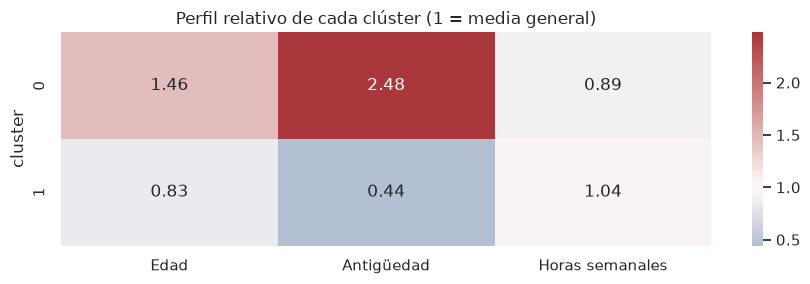

In [11]:
best_kmeans = KMeans(
    k=best_k, seed=42, featuresCol="cluster_features", predictionCol="cluster", maxIter=50
).fit(cluster_data)
clustered = best_kmeans.transform(cluster_data).cache()

cluster_profile = (
    clustered.groupBy("cluster")
    .agg(
        F.count("*").alias("observaciones"),
        F.avg("edad").alias("edad_media"),
        F.avg("antiguedad_total").alias("antiguedad_media"),
        F.avg("horas_semanales").alias("horas_media"),
        F.avg("salario_mensual").alias("salario_medio"),
        F.percentile_approx("salario_mensual", 0.5, 10000).alias("salario_mediano"),
    )
    .withColumn("porcentaje", F.round(F.col("observaciones") * 100 / F.lit(n_observaciones), 2))
    .orderBy("cluster")
)
cluster_profile_pdf = cluster_profile.toPandas()
display(cluster_profile_pdf.round(2))

global_means = df_2025.agg(*[F.avg(column).alias(column) for column in cluster_columns]).first().asDict()
relative_profile = cluster_profile_pdf.set_index("cluster")[["edad_media", "antiguedad_media", "horas_media"]].copy()
relative_profile["edad_media"] /= global_means["edad"]
relative_profile["antiguedad_media"] /= global_means["antiguedad_total"]
relative_profile["horas_media"] /= global_means["horas_semanales"]
relative_profile.columns = ["Edad", "Antigüedad", "Horas semanales"]
plt.figure(figsize=(9, max(3, best_k * 0.8)))
sns.heatmap(relative_profile, annot=True, fmt=".2f", cmap="vlag", center=1)
plt.title("Perfil relativo de cada clúster (1 = media general)")
plt.tight_layout()
plt.show()

In [12]:
global_salary_median = summary_pdf.loc["Salario mensual (Q)", "mediana"]
profile_descriptions = []
for row in cluster_profile_pdf.itertuples(index=False):
    age_description = "mayor edad" if row.edad_media >= global_means["edad"] else "menor edad"
    tenure_description = "más antigüedad" if row.antiguedad_media >= global_means["antiguedad_total"] else "menos antigüedad"
    hours_description = "jornada más extensa" if row.horas_media >= global_means["horas_semanales"] else "jornada más corta"
    if row.salario_mediano > global_salary_median:
        salary_description = "por encima de"
    elif row.salario_mediano < global_salary_median:
        salary_description = "por debajo de"
    else:
        salary_description = "igual a"
    profile_descriptions.append(
        f"- **Clúster {row.cluster} ({row.porcentaje:.2f}%):** perfil de {age_description}, "
        f"{tenure_description} y {hours_description}. Su salario mediano es Q{row.salario_mediano:,.2f}, "
        f"{salary_description} la mediana general."
    )

display(Markdown("""
### Interpretación de la actividad 4

Los nombres de los clústeres son descriptivos y relativos a la media de la muestra, no categorías oficiales de trabajadores.

""" + "\n".join(profile_descriptions) + """

El salario se agregó únicamente después del ajuste. Por tanto, sus diferencias ayudan a caracterizar los perfiles, pero no determinaron la asignación. KMeans produce particiones compactas bajo distancia euclidiana y puede ser sensible a formas no esféricas, valores extremos y la elección de variables.
"""))


### Interpretación de la actividad 4

Los nombres de los clústeres son descriptivos y relativos a la media de la muestra, no categorías oficiales de trabajadores.

- **Clúster 0 (27.31%):** perfil de mayor edad, más antigüedad y jornada más corta. Su salario mediano es Q3,250.00, por encima de la mediana general.
- **Clúster 1 (72.69%):** perfil de menor edad, menos antigüedad y jornada más extensa. Su salario mediano es Q3,000.00, igual a la mediana general.

El salario se agregó únicamente después del ajuste. Por tanto, sus diferencias ayudan a caracterizar los perfiles, pero no determinaron la asignación. KMeans produce particiones compactas bajo distancia euclidiana y puede ser sensible a formas no esféricas, valores extremos y la elección de variables.


## Conclusión de las actividades 2–4

La exploración caracteriza la distribución no ponderada de los registros elegibles, compara salarios entre grupos y períodos, y cuantifica asociaciones lineales sin atribuir causalidad. La segmentación complementa ese análisis al resumir combinaciones de edad, antigüedad y jornada laboral. `FACTOR` se conserva en la preparación porque sería necesario para producir estimaciones poblacionales bajo el diseño de encuesta, pero por instrucción no se usa en estas estadísticas, correlaciones ni clústeres principales.

Antes de entregar, se debe ejecutar este notebook nuevamente después de corregir el inciso 1 y verificar que cada trimestre provenga de su archivo real.